Notebook for KPZ simulations (current)  

Note that this notebook has support for only simulations that have been saved using `.npz` + `.json` method. If you need to work with `.pkl` files, go to `ss_true_time.ipynb`. 

In [2]:
from stochastic_growth_true_time_simulation import *
from stochastic_growth_data_analysis import *
import mplcursors
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
%matplotlib inline

# Single simulations

In this section, we go over the following:

- Initializing new simulation
- Loading simulations
- Running simulation
- (Manually) saving simulations
- Single simulation analysis

## Initialize new simulation

In [16]:
L = 2**15
mu = 6.0
seed = 5
ls = list(np.logspace(np.log10(2**8), np.log10(2**15), num=20, dtype=int))
sim = StochasticGrowthStripGeometry(L=L, mu=mu, seed=seed, initial_height=5000)
sim.ls = ls

## Load simulation

In [4]:
save_path = "/Users/ghan/Desktop/replica_seed000002.npz"
sim = StochasticGrowthStripGeometry.load(save_path)
obs = sim.get_obs()

Simulation loaded from /Users/ghan/Desktop/replica_seed000002.npz/.json  (t=2534.2651, accepted=47645180)


## Running simulation

In [ ]:
n_steps = int(10_000_000_000)
record_interval_true = 5
snapshot_steps = [i for i in range(0, n_steps + 1, 500_000)]
snapshot_dir = "snapshots_L16384_mu_3p6"
save_snapshots = False
obs = sim.run(
    n_steps=n_steps,
    record_interval_true=record_interval_true,
    snapshot_steps=snapshot_steps,
    snapshot_dir=snapshot_dir,
    save_snapshots=save_snapshots
)

KeyboardInterrupt: 

## Saving simulation

In [4]:
_L_tag = f"{sim.L}"
_mu_tag = f"{sim.mu:.2f}".replace(".", "p")
_t_tag = f"{sim.attempts // 1_000_000}M"
_seed_tag = f"{seed:06d}"

save_path = f"L{_L_tag}_mu{_mu_tag}_seed{_seed_tag}_time{_t_tag}"
sim.save(save_path)

Simulation saved to L16384_mu5p00_seed000001_time80000M.npz/.json  (t=3198.3783, accepted=50129182)


## Single simulation analysis  

For temporal plotting, the time axis will usually be of one of two things:

- $t$: This is measured by number of proliferation attempts or simulation steps. This gets updated by $dt = 1$ every step. (Computational time)
- $\tau$: The true time is related to the computational time by the following update rule: $d\tau = dt/N(t)$, where $N(t)$ is the current population number at time $t$. This relationship gaurentees that the total jump rate is always proportional to the population size. (Think: in order for the true time to change by 1 unit, we would need roughly $N$ proliferation attempts.)

### Surface heights over time

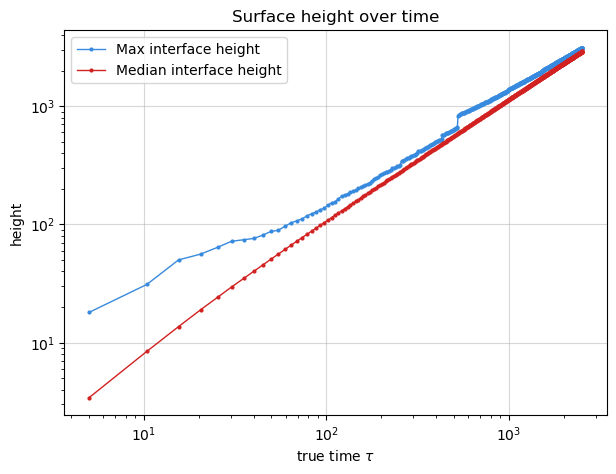

In [5]:
t = obs['t']
max_height = obs['max_height_history']
mean_height = obs['mean_height_history'] 

def model(x, m):
    return m * x + 1 # we know that at time 0, the mean height is 1

popt, pcov = curve_fit(model, t, mean_height) 
m = popt[0]

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(t, max_height, color='#378ADD', lw=1.0, marker='o', markersize=2, label="Max interface height")
ax.plot(t, mean_height, color="#d12121", lw=1.0, marker='o', markersize=2,label="Median interface height")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
ax.set_xlabel(r"true time $\tau$")
ax.set_ylabel("height")
ax.set_title("Surface height over time")
ax.legend()
plt.show()
# print(f"Slope of mean height: {m}")
# print(f"Mean interface power: {fit_loglog_slope(t, mean_height)}")
# print(f"Max height interface power: {fit_loglog_slope(t, max_height)}")

### Plotting true time versus computational time

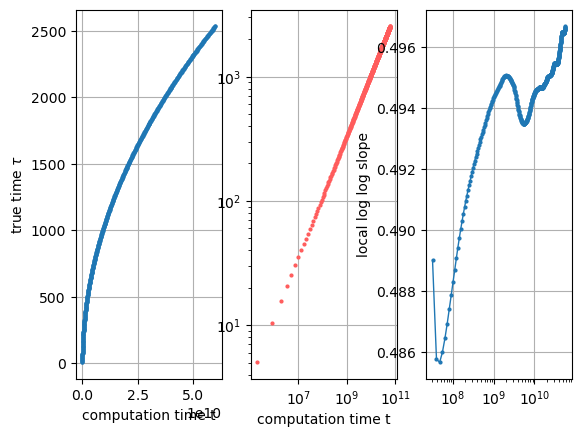

In [8]:
t_mean = t
att = obs["t_compute"]
# print(f"Scaling of effective time versus computational time {fit_loglog_slope(att, t_mean)}")
s=30

fig, ax = plt.subplots(1,3)
ax[0].plot(att, t_mean, marker='o', markersize=2, lw=0)
ax[1].plot(att, t_mean, marker='o', markersize=2, color="#FF5C5C", lw=0)
ax[0].grid(True)
ax[1].grid(True)
ax[0].set_xlabel("computation time t")
ax[1].set_xlabel("computation time t")
ax[0].set_ylabel(r"true time $\tau$")
ax[1].set_xscale("log")
ax[1].set_yscale("log")
xs, ms = local_slopes(np.log(att), np.log(t_mean), s=s)
ax[2].plot(np.exp(xs), ms, marker='o', markersize=2, lw=1.0)
ax[2].set_xscale("log")
ax[2].set_ylabel("local log log slope")
ax[2].grid(True)
plt.show()

### Plotting population size 

slope: 18729.902602792055
scaling 1.0256024077641128


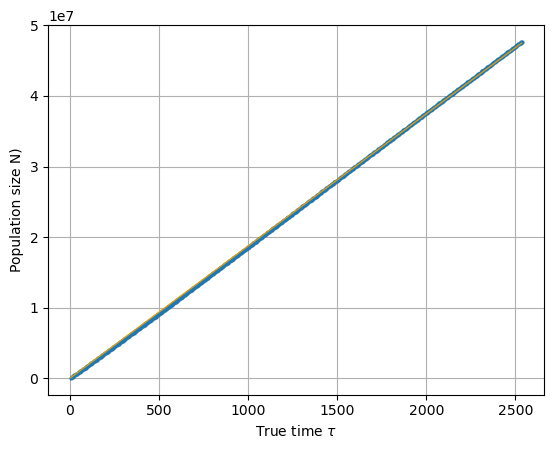

In [9]:
L = sim.L
def model(x, m):
    return m * x + L

N_t = obs["population_size"]

popt, pcov = curve_fit(model, t, N_t)
m = popt[0]

fig, ax = plt.subplots()
ax.plot(t, N_t, lw=0.0, marker='o', markersize=2)
ax.plot(t, m*t + L, lw=1, color="#D69C12")
ax.grid(True)
ax.set_ylabel(r"Population size N)")
ax.set_xlabel(r"True time $\tau$")
print(f"slope: {m}")
print(f"scaling {fit_loglog_slope(t, N_t)}")

### Spacing of samples in true time

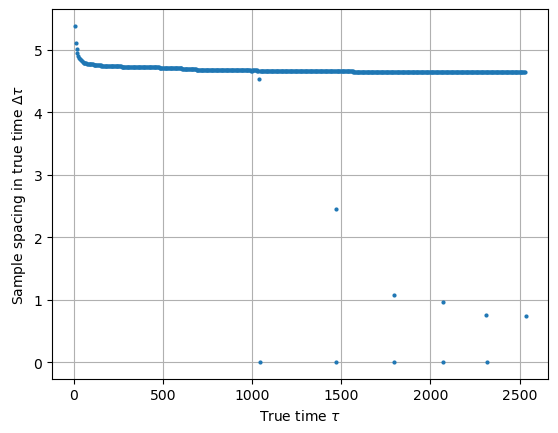

In [10]:
delta_tau = np.asarray([t[i+1]-t[i] for i in range(len(t)-1)])

fig, ax = plt.subplots()
ax.plot(t[:-1], delta_tau[:], lw=0.0, marker='o', markersize=2)
fit_loglog_slope(t[:-1], delta_tau[:])
ax.grid(True)
ax.set_xlabel(r"True time $\tau$")
ax.set_ylabel(r"Sample spacing in true time $\Delta \tau$")
mplcursors.cursor()

plt.show()

### Plotting $w(l_0, \tau)$

Generates a curve $w(l, \tau)$ for each $l$ specified in the simulation `sim.ls`.

Mean log-log slope: 0.47845638614091063
l = 128, alpha = 0.1846386554789972
l = 133, alpha = 0.19078576266457606
l = 139, alpha = 0.2053296554453047
l = 145, alpha = 0.21072710284873453
l = 151, alpha = 0.2170668443707679
l = 157, alpha = 0.23669279234741114
l = 164, alpha = 0.24346271257300006
l = 171, alpha = 0.24661855039084044
l = 179, alpha = 0.2452177245609839
l = 186, alpha = 0.26775295528559895
l = 194, alpha = 0.26965619356021475
l = 203, alpha = 0.27622467892006275
l = 211, alpha = 0.2977635898392654
l = 220, alpha = 0.3030224711994915
l = 230, alpha = 0.3139466420505468
l = 240, alpha = 0.32033111268752185
l = 250, alpha = 0.329044774411535
l = 261, alpha = 0.349096852913058
l = 272, alpha = 0.3603286542789988
l = 284, alpha = 0.3719371679495833
l = 296, alpha = 0.37490304315397777
l = 309, alpha = 0.3696560544789284
l = 322, alpha = 0.38814021111211117
l = 336, alpha = 0.3982023670017448
l = 350, alpha = 0.40188768521170476
l = 365, alpha = 0.4212370716622847
l = 381, alpha

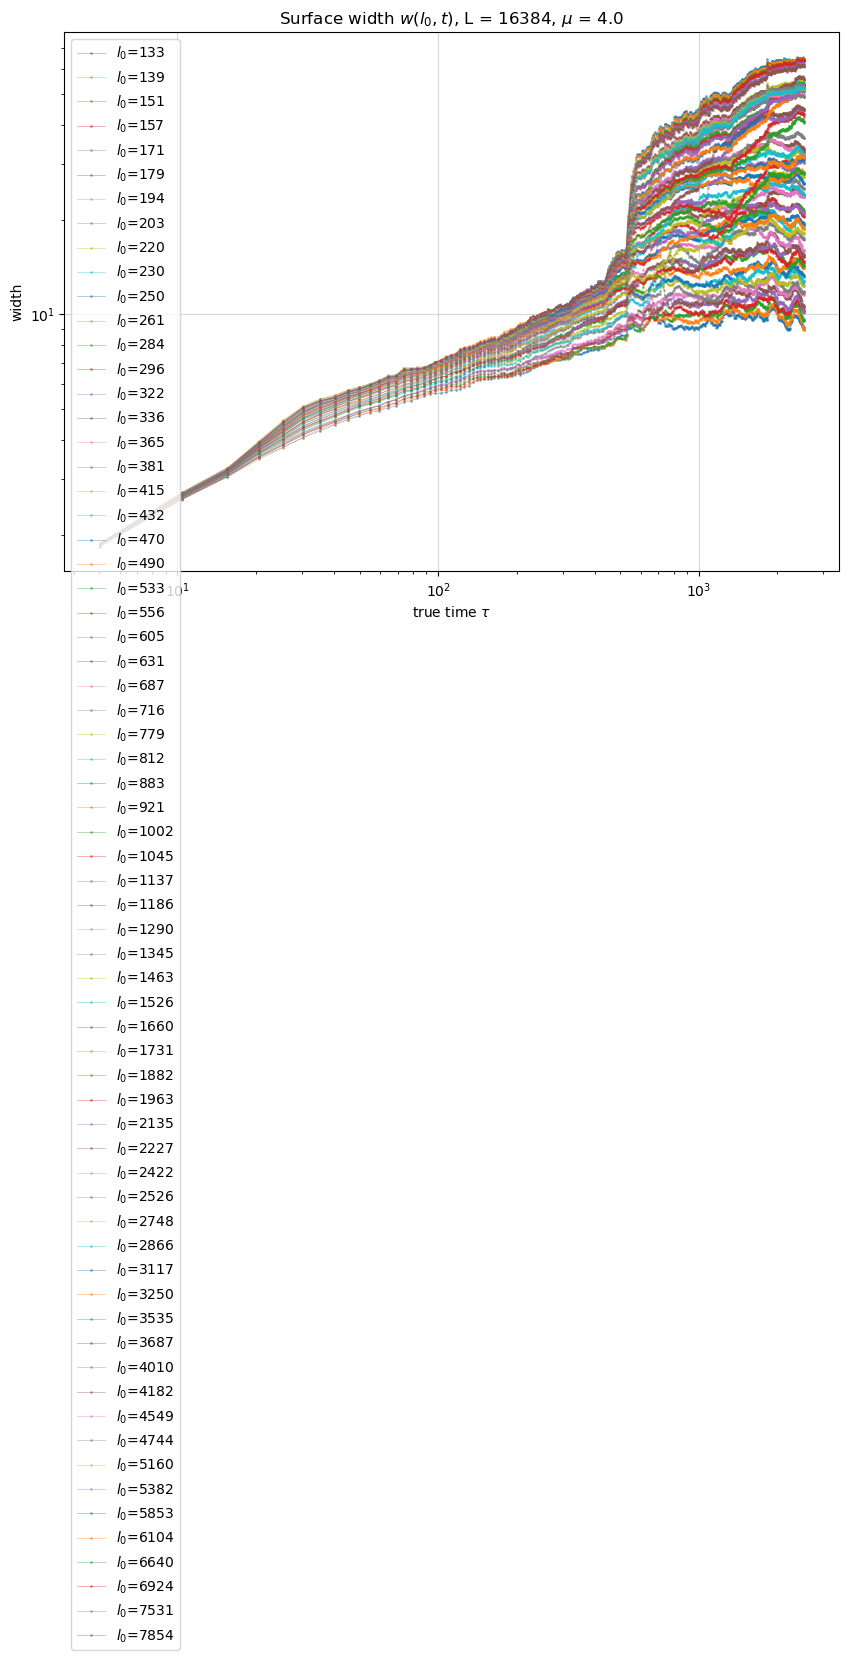

In [11]:
log_log_slopes = []
t_dim, l_dim = np.shape(obs['surface_width_history'])
l_0s = sim.ls
t = obs['t']
fig, ax = plt.subplots(figsize=(10, 7))
for i, l_0 in enumerate(l_0s):
    if i % 3 == 0:
        continue
    w_l_0 = obs['surface_width_history'][:, i]
    log_log_slopes.append(fit_loglog_slope(t[:], w_l_0))
    ax.plot(t[:], w_l_0, lw=0.5, label=f"$l_0$={l_0}", alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"true time $\tau$")
ax.set_ylabel("width")
ax.set_title(fr"Surface width $w(l_0, t)$, L = {sim.grid.shape[1]}, $\mu$ = {sim.mu}")
ax.legend()
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid(alpha=0.5)
print(f"Mean log-log slope: {np.mean(log_log_slopes)}")

for i, alpha in enumerate(log_log_slopes):
    print(f"l = {l_0s[i]}, alpha = {alpha}")

### Growth exponent measurement 

### Using local slopes

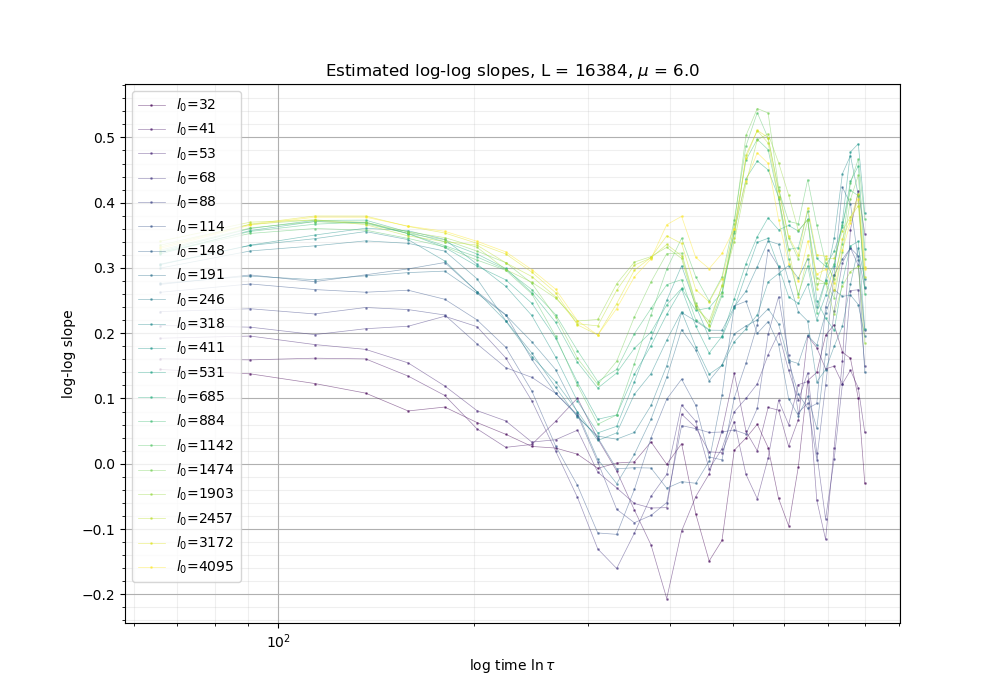

In [75]:
tlog = np.log(t)
l_0s = sim.ls
s=5

fig, ax = plt.subplots(figsize=(10, 7))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))
for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    wlog = np.log(w_l_0)
    xs, ms = local_slopes(tlog, wlog, s=s)
    ax.plot(np.exp(xs), ms, lw=0.5, label=f"$l_0$={l_0}", color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"log time $\ln \tau$")
ax.set_xscale("log")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.legend()

mplcursors.cursor(hover=True)

plt.show()

### Using secants

This is not a good idea because of transients in the surface growth.

NameError: name 'loglog_secants' is not defined

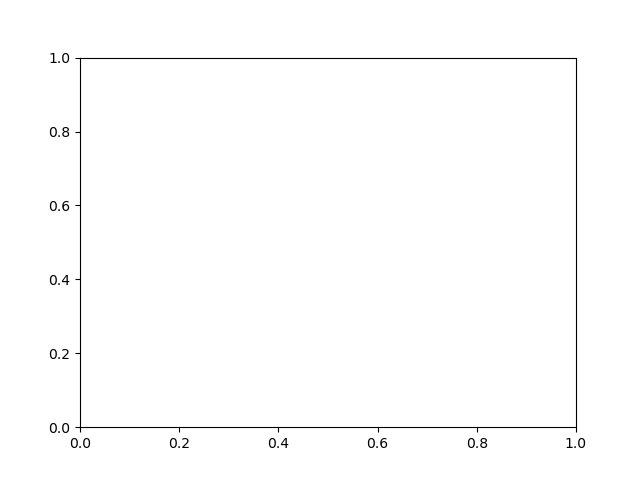

In [31]:
fig, ax = plt.subplots()
cmap_lines = plt.cm.rainbow(np.linspace(0, 1, len(ls)))

secant_start = 7

for i, l_0 in enumerate(l_0s):
    w_l_0 = obs['surface_width_history'][:, i]
    xs, ms = loglog_secants(t[secant_start:], w_l_0[secant_start:])
    ax.plot(xs, ms, lw=0.5, label=f"$l_0$={l_0}",color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"log time $\ln \tau$")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.set_xscale("log")
# ax.set_xlim(-1, 2)
# ax.set_ylim(-1,2)
ax.legend()



# Parallel batch simulations

This section parallelizes multiple replicas of the same `(L, mu, ls, record intervals)` simulation across processes, each with its own seed. Each replica reuses the single-simulation machinery defined above (`StochasticGrowthStripGeometry`, its `run`, and its `save`/`load`), and replicas are written to a single ensemble directory using the same `.npz` + `.json` format as single sims.

Each replica is run in its own worker process so the numba-jitted kernels and `numpy` RNG state are independent. We use the `fork` multiprocessing context so the worker function defined in this notebook is available to the children without re-importing `__main__`.

Files are laid out as:
```
<ensemble_dir>/
    replica_seed000001.npz
    replica_seed000001.json
    replica_seed000002.npz
    ...
    ensemble_meta.json   # L, mu, n_steps, record_interval_true, ls, seeds
```

**Note** The parallel processing portion has been moved into its own script. See `simulation2_batch.py`. 

In [15]:
import json as _json

def batch_load(ensemble_dir):
    """Load every replica in `ensemble_dir` into a dict {seed: sim}.

    Pairs each `.npz` with its `.json`. Replicas without both files are skipped.
    Returns (replicas_dict, ensemble_meta_dict_or_None).
    """
    ensemble_dir = Path(ensemble_dir)
    meta_path = ensemble_dir / "ensemble_meta.json"
    meta = None
    if meta_path.exists():
        with open(meta_path, "r") as f:
            meta = _json.load(f)

    replicas = {}
    for npz_path in sorted(ensemble_dir.glob("replica_seed*.npz")):
        base = npz_path.with_suffix("")
        if not (base.with_suffix(".json")).exists():
            print(f"[skip] {npz_path.name} has no matching .json")
            continue
        seed = int(base.name.split("seed")[-1])
        replicas[seed] = StochasticGrowthStripGeometry.load(str(base))
    return replicas, meta

## Loading an ensemble

`batch_load` returns a `{seed: sim}` dictionary plus the ensemble metadata. Each `sim` is a fully reconstituted `StochasticGrowthStripGeometry`, so the per-replica analysis cells above (`get_obs`, surface-width plotting, growth-exponent fits, …) work on each entry unchanged.

In [81]:
ensemble_dir = r"ensemble_L16384_mu5p00_t10000M_dtau0.2_N50"
replicas, ensemble_meta = batch_load(ensemble_dir)
print(f"loaded {len(replicas)} replicas from {ensemble_dir}")
print("seeds:", sorted(replicas.keys()))
print("ensemble meta:", ensemble_meta)

# Example: stack mean-height histories across replicas (they share record_interval_true,
# so the time axes are comparable but not exactly identical due to integer truncation).
obs_per_seed = {seed: sim.get_obs() for seed, sim in replicas.items()}
for seed, obs in obs_per_seed.items():
    print(f"  seed {seed:06d}: {len(obs['t'])} samples, accepted={obs['accepted']}")

Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000020.npz/.json  (t=1134.4600, accepted=17707892)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000021.npz/.json  (t=1135.5462, accepted=17670624)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000022.npz/.json  (t=1134.1012, accepted=17728602)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000023.npz/.json  (t=1132.9856, accepted=17721032)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000024.npz/.json  (t=1134.5574, accepted=17710791)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000025.npz/.json  (t=1133.9559, accepted=17736023)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000026.npz/.json  (t=1134.0492, accepted=17709462)
Simulation loaded from ensemble_L16384_mu5p00_t10000M_dtau0.2_N50/replica_seed000027.npz/.json  (

## Averaging across an ensemble

Each replica has the following histories:
- time
- widths
- max_height
- mean_height

To name a few.

Every history is aligned to its own time. Depending on acceptance rates, the true time of each record is different for different replicas. I'm going to assume that this difference is negligible for large enough simulations and times. 

Time is averaged over first, then it is easy to align the rest of the measurements and average over them as well.

<>:36: SyntaxWarning: invalid escape sequence '\p'
<>:36: SyntaxWarning: invalid escape sequence '\p'
/var/folders/hd/ys7gfj7968j5gn566_yq9gvm0000gn/T/ipykernel_16963/3121624328.py:36: SyntaxWarning: invalid escape sequence '\p'
  + f"\n(shaded: $\pm$ STD)"


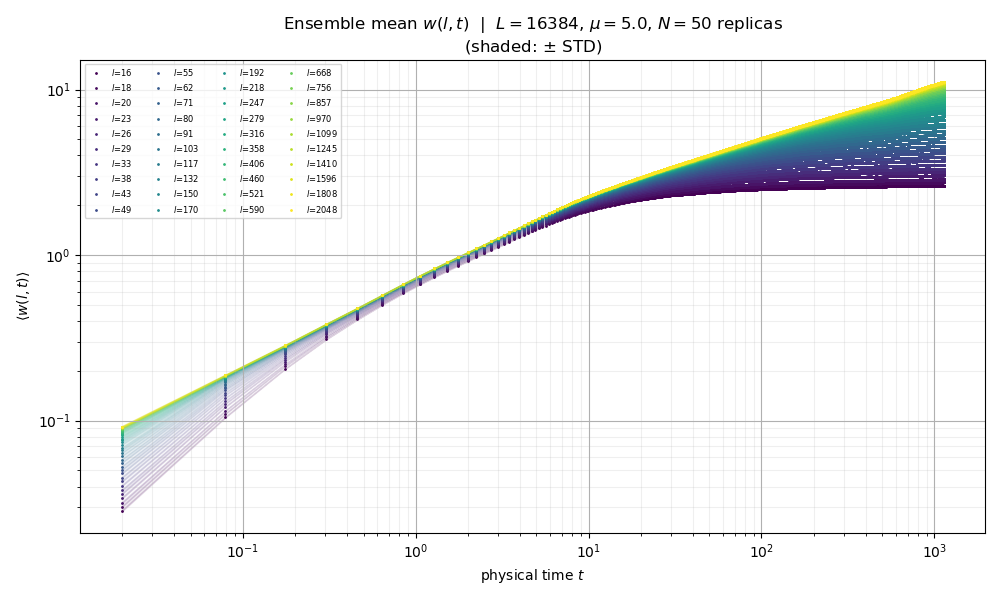

In [99]:
ls = ensemble_meta["ls"]
L = ensemble_meta["L"]
mu = ensemble_meta["mu"]
times = [obs['t'] for obs in obs_per_seed.values()]
N_ensemble = len(obs_per_seed)


t_mean = np.mean(np.vstack(times), axis=0)

# average over surface widths

sw = np.stack(
    [obs['surface_width_history'] for obs in obs_per_seed.values()]
)
sw_mean = np.mean(sw, axis=0)
sw_std = np.std(sw, axis=0) / np.sqrt(N_ensemble) # this is standard deviation of the mean so divide by \sqrt(n)

fig, ax = plt.subplots(figsize=(10, 6))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))

for i, l_val in enumerate(ls):
    ax.plot(t_mean, sw_mean[:, i], color=cmap_lines[i], lw=0, marker='o',
            markersize=1, label=f"$l$={l_val}")
    ax.fill_between(
        t_mean,
        sw_mean[:, i] - sw_std[:, i],
        sw_mean[:, i] + sw_std[:, i],
        color=cmap_lines[i], alpha=0.15,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("physical time $t$")
ax.set_ylabel(r"$\langle w(l,t) \rangle$")
ax.set_title(
    rf"Ensemble mean $w(l,t)$  |  $L={L}$, $\mu={mu}$, $N={N_ensemble}$ replicas"
    + f"\n(shaded: $\pm$ STD)"
)
ax.legend(fontsize=6, ncol=4, loc="upper left")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
plt.tight_layout()
mplcursors.cursor(hover=True)
plt.show()


## Fitting using local slopes

this can be used to measure the growth exponent

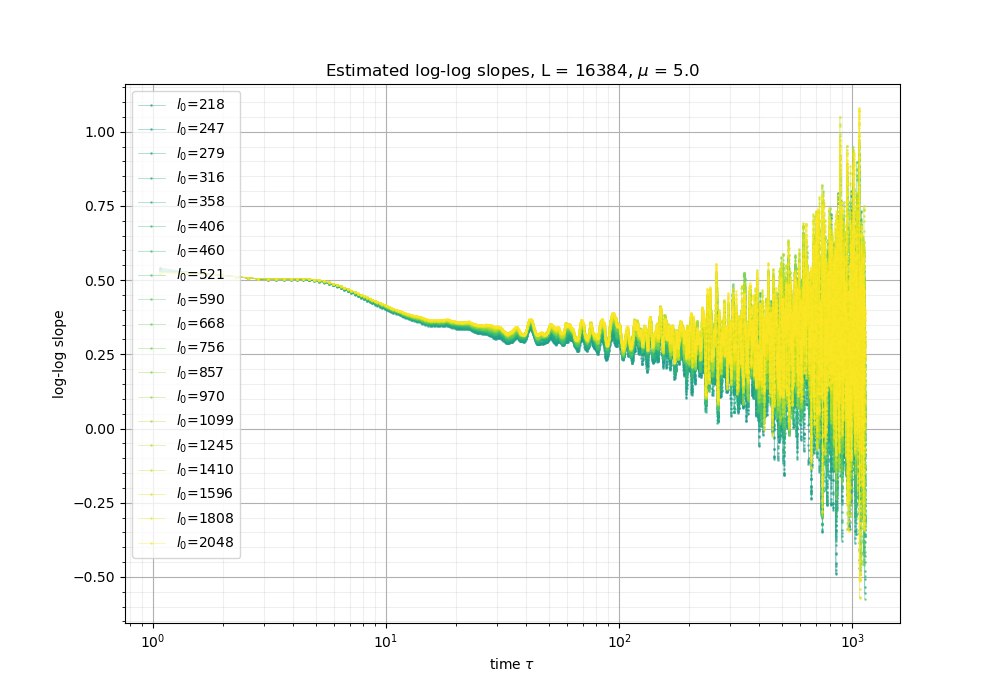

In [98]:
def local_slopes(x, y, s=1):
    """
    Calculates the local slopes using a windowed linear regression.
    """
    y_dim = len(y)
    ms = np.zeros(y_dim - s)
    xs = np.zeros(y_dim - s)

    for i in range(y_dim - s):
        #ms[i] = (y[i+s] - y[i]) / (x[i+s] - x[i])
        ms[i], _ = np.polyfit(x[i:i+s+1], y[i:i+s+1], deg=1)
        xs[i] = np.mean(x[i:i+s+1]) # this better reflects the centroid of window if
        # points are not evenly spaced
        # xs[i] = (x[i+s+1] + x[i])/2

    return xs, ms

tlog = np.log(t_mean)
l_0s = ensemble_meta["ls"]
s=20

fig, ax = plt.subplots(figsize=(10, 7))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))
for i, l_0 in enumerate(l_0s):
    if i <= 20:
        continue
    w_l_0 = sw_mean[:, i]
    wlog = np.log(w_l_0)
    xs, ms = local_slopes(tlog, wlog, s=s)
    ax.plot(np.exp(xs), ms, lw=0.5, label=f"$l_0$={l_0}", color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"time $\tau$")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.set_xscale("log")
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.legend()
mplcursors.cursor(hover=True)
plt.show()


Fitting using secants.

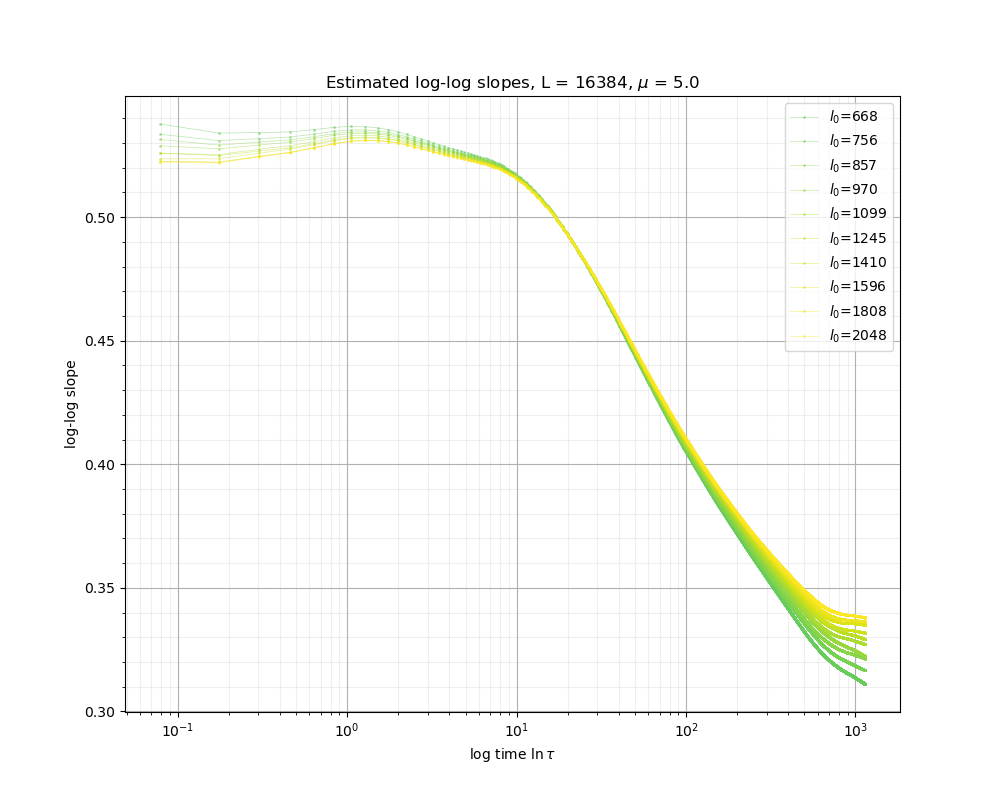

In [92]:
fig, ax = plt.subplots(figsize=(10, 8))
cmap_lines = plt.cm.viridis(np.linspace(0, 1, len(ls)))

for i, l_0 in enumerate(l_0s):
    if i >= 30:
        xs, ms = loglog_secants(t_mean, sw_mean[:, i])
        ax.plot(xs, ms, lw=0.5, label=f"$l_0$={l_0}",color=cmap_lines[i], alpha=0.5, marker='o', markersize=1)
ax.set_xlabel(r"log time $\ln \tau$")
ax.set_ylabel("log-log slope")
ax.set_title(fr"Estimated log-log slopes, L = {L}, $\mu$ = {mu}")
ax.minorticks_on()
ax.grid(True)
ax.grid(which='minor', alpha=0.2)
ax.set_xscale("log")
# ax.set_xlim(-1, 2)
# ax.set_ylim(-1,2)
ax.legend()
plt.show()

## Roughness exponent

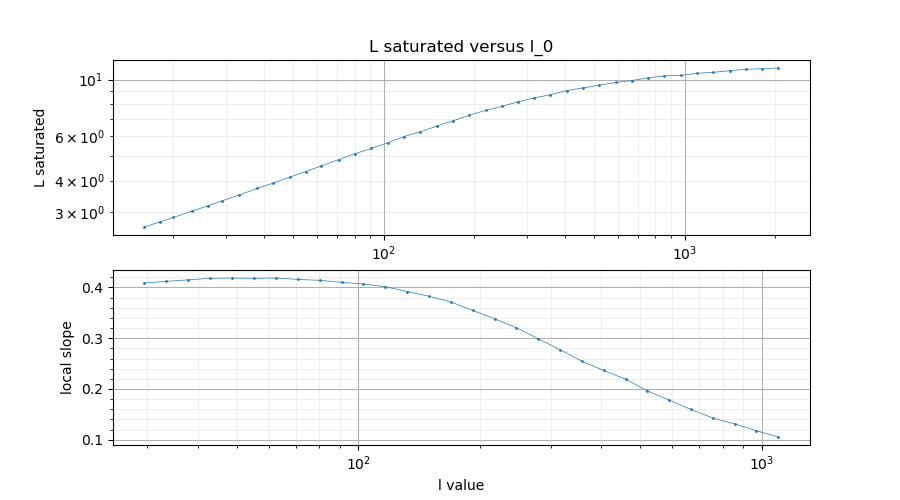

In [108]:
def w_sat(w_l_0, last=20):
    """Returns the approximate saturated value of a curve 
    by averaging over the last s points."""
    ws = w_l_0[-last:]
    l_sat = np.mean(ws)
    l_sat_std = np.std(ws)
    return l_sat, l_sat_std

ls = ensemble_meta["ls"]
L = ensemble_meta["L"]
mu = ensemble_meta["mu"]
times = [obs['t'] for obs in obs_per_seed.values()]
N_ensemble = len(obs_per_seed)


t_mean = np.mean(np.vstack(times), axis=0)

# average over surface widths

sw = np.stack(
    [obs['surface_width_history'] for obs in obs_per_seed.values()]
)
sw_mean = np.mean(sw, axis=0)
sw_std = np.std(sw, axis=0) / np.sqrt(N_ensemble) # this is standard deviation of the mean so divide by \sqrt(n)

L_saturate = []
last = 10

for i in range(len(ls)):
    _L_sat, _ = w_sat(sw_mean[:, i], last) 
    L_saturate.append(_L_sat)

s=10
xs, ms = local_slopes(np.log(ls), np.log(L_saturate), s=s)

fig, ax = plt.subplots(2,1,figsize=(9, 5))
ax[0].plot(ls, L_saturate, lw=0.5, marker='o', markersize=1)
#ax[0].set_xlabel(r"$l$ value")
ax[0].set_ylabel("L saturated")
ax[0].set_title(fr"L saturated versus l_0")
ax[0].minorticks_on()
ax[0].grid(True)
ax[0].grid(which='minor', alpha=0.2)
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[1].plot(np.exp(xs), ms, lw=0.5, marker='o', markersize=1)
ax[1].set_xlabel(r"l value")
ax[1].set_ylabel(r"local slope")
ax[1].minorticks_on()
ax[1].set_xscale("log")
ax[1].grid(True)
ax[1].grid(which='minor', alpha=0.2)
mplcursors.cursor(hover=True)
plt.show()